1. Lire les fichiers BIN, conversion dans la bonne unité et transformer en AC
2. Récuperer les annotations
3. Associer annotations fichier excel et valeurs des fichiers BIN (fait dans 1. et 2.)
4. Entrainement de Random Forest : (split en train et test, application de RF au train puis au test)
5. Analyser des résultats (matrices de confusion, accuracy score)

In [24]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, DBSCAN
from agcounts_filter import convert_AC
from datetime import datetime
from scipy.stats import mode

1-4 Récupération de X et Y 

In [48]:
# LES X ET Y SONT SYNCHRONISE JUSTE LES Y NE CORRESPONDENT PAS DIRRECTEMENT AUX SECONDES DU EXCEL : CE SONT (LES SECONDES DU EXCEL)-(LE TEMPS DE DEPART)
# POUR LE FICHIER DATA 10 LES ANNOTATIONS SONT DECALEES DE 7 SEC

temps_depart = datetime.now()

folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

#//////////////////////////////AJOUTER UNE LISTE QUI DIT DOM ET NON DOM POUR CHAQUE FICHIER (la les Y sont bien classés mais forcément les X)
#lst_indic_dom = ["LW","LW","LW"]

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder[4:7]: #[0:7]
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":

        # Visualisation des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() # Conversion du type pd.serie en type list
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                """if int(round(float(my_sheet.cell(label.row, 12).value))) < float(my_sheet.cell(label.row, 12).value):
                    start_dom = int(round(float(my_sheet.cell(label.row, 12).value))) + 1
                else:
                    start_dom = int(round(float(my_sheet.cell(label.row, 12).value))) 
                decalage_dom += start_dom - float(my_sheet.cell(label.row, 12).value)
                #Ajouter un nb start_sensor de none au début
                for decalage in range(start_dom):
                    Y_dom.append(None) #.append("différent start droit")"""
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                """f int(round(float(my_sheet.cell(label.row, 12).value))) < float(my_sheet.cell(label.row, 12).value):
                    start_non_dom = int(round(float(my_sheet.cell(label.row, 12).value))) + 1
                else:
                    start_non_dom = int(round(float(my_sheet.cell(label.row, 12).value))) 
                decalage_non_dom += start_non_dom - float(my_sheet.cell(label.row, 12).value)
                #Ajouter un nb start_sensor de none au début
                for decalage in range(start_non_dom):
                    Y_non_dom.append(None) #append("différent start gauche")"""
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_dom.append(None) #.append("décalage annotations")
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire":
                        # Y_dom[idx_Y_dom].append("non mouvement")
                        Y_dom.append("non mouvement")
                    elif label.value[3:7] =="mouv":
                        #Y_dom[idx_Y_dom].append("mouvement")
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        #Y_dom[idx_Y_dom].append("non noté") #.append(None) 
                        Y_dom.append(None) #("non noté")

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire":
                        Y_non_dom.append("non mouvement")
                    elif label.value[3:7] =="mouv":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row
        
        # CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)]
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom)]
        Y_non_dom = Y_non_dom[:len(X_non_dom)]

        print(f"X_dom {X_dom[608 : 615]}")
        print(f"Y_dom {Y_dom[608 : 615]}")


temps_fin = datetime.now()

temps = temps_fin - temps_depart
print(f"temps que ca prend : {temps}")

On est dans le fichier : Data_11_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_X.xlsx
X_dom [202.41047403728888, 221.3504009483606, 36.49657518178932, 136.7808466123821, 112.28535078094559, 129.0, 79.42921376924235]
Y_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement']
temps que ca prend : 0:01:12.986387


In [28]:
print(f"X_non_dom {X_non_dom[600 - 7:615 - 7]}")
print(f"Y_non_dom {Y_non_dom[600 - 7:615 - 7]}")
print(f'len X_dom : {len(X_dom)}')

X_non_dom [13.0, 0.0, 0.0, 0.0, 0.0, 53.03772242470448, 37.20215047547655, 47.4236228055175, 13.416407864998739, 13.892443989449804, 46.17358552246078, 226.74434943345335, 62.80127387243033, 102.83968105745953, 174.01149387324966]
Y_non_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement']
len X_dom : 1425


1209


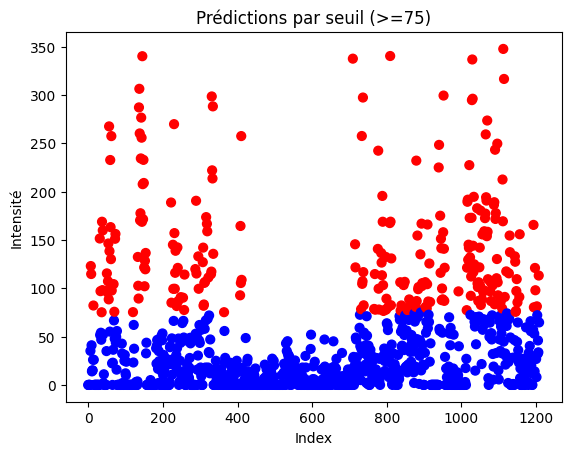

Accuracy pour seuil > 75 : 0.26


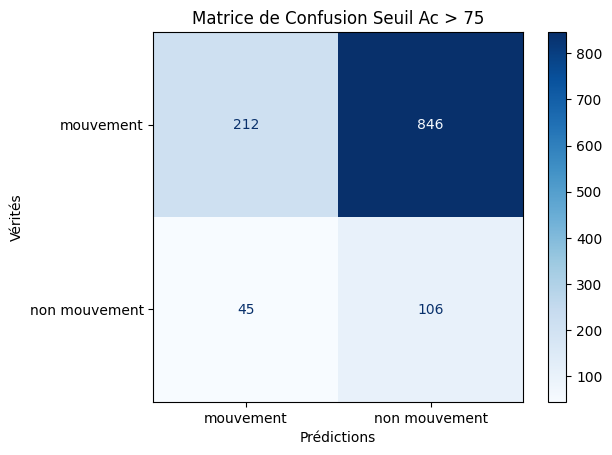

Affichage des données

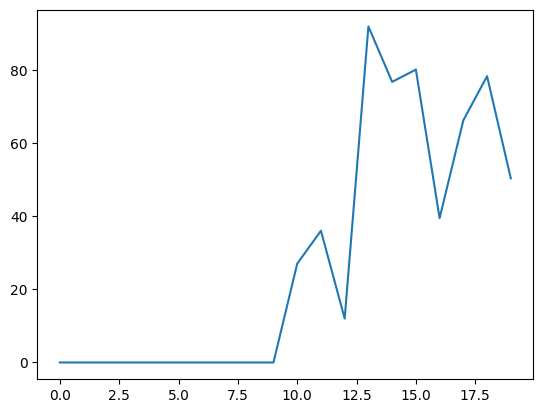

['non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', None, None, None, None, None, None, None, None]


In [4]:
plt.plot(X_non_dom[1180:1200])
plt.show()
print(Y_non_dom[1180:1200])

4-5 Création des modèles et analyses des résultats

Nombre de données annotées passées à l'algorithme
len Y_balanced : 134
len X_balanced : 134
Accuracy pour RF : 0.81


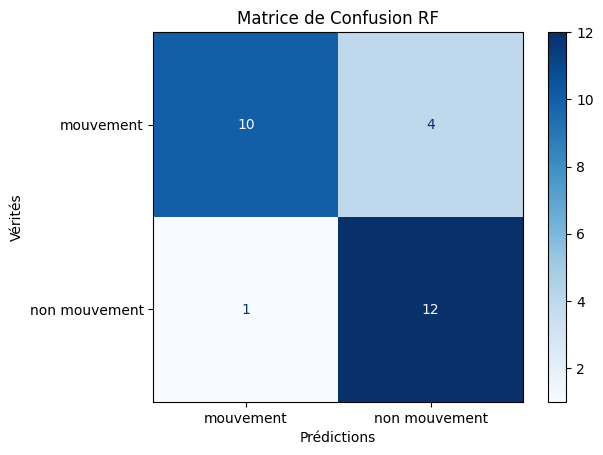

Labels trouvés : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66]


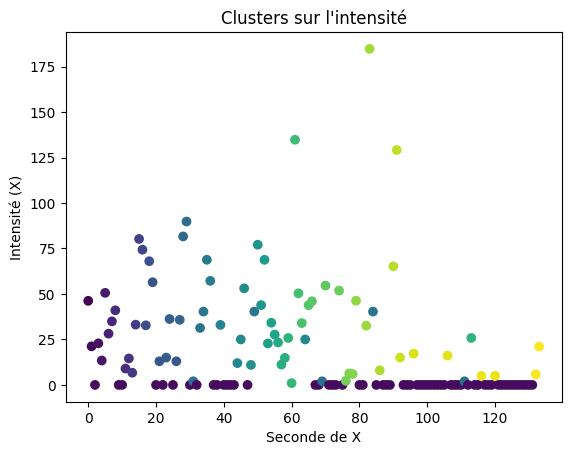

Accuracy pour clustering : 0.86


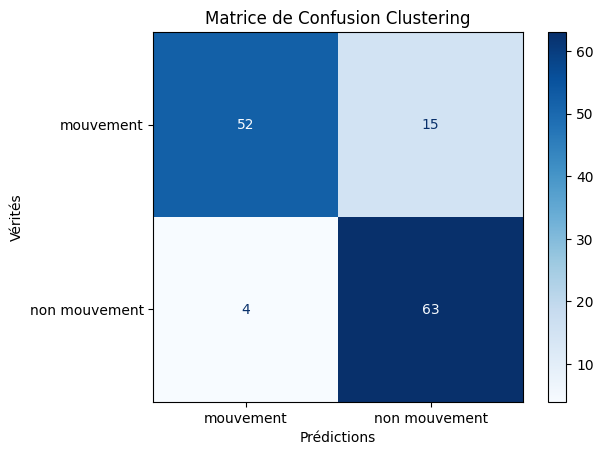

In [68]:
from sklearn.model_selection import GridSearchCV

# Convertir en array pour faciliter le filtrage
X_array = np.array(X_non_dom)
Y_array = np.array(Y_non_dom)
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None = Y_array != None
# Appliquer le masque
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]

#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array

# Compter les "non mouvement"
n_non_mvt = np.sum(Y_clean == 'non mouvement')
# Sélectionner les indices dans l’ordre original
indices_mvt = np.where(Y_clean == 'mouvement')[0]
indices_non_mvt = np.where(Y_clean == 'non mouvement')[0]
# Garder les premiers `mouvement` rencontrés dans l'ordre
indices_mvt_crop = indices_mvt[:n_non_mvt]
# Fusionner les indices en gardant l’ordre du tableau initial
indices_final = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))
# Réorganise X et Y
X_balanced = X_clean[indices_final]
Y_balanced = Y_clean[indices_final]

# Aplatir les données (mettre au bon format pour les modèles)
X_flat = np.vstack(X_balanced)  # (n_total_samples, n_features)
Y_flat = np.hstack(Y_balanced)  # (n_total_samples,)

print("Nombre de données annotées passées à l'algorithme")
print(f'len Y_balanced : {len(Y_balanced)}')
print(f'len X_balanced : {len(X_balanced)}')

#*************************************** Random Forest *****************************************************************
# Split data into train and test samples
X_train, X_test, y_train, y_test = train_test_split(X_flat, Y_flat, test_size=0.2)

# Initialize the model
non_dom_Random_Forest = RandomForestClassifier(n_estimators=10, random_state=42)
# Train the model
non_dom_Random_Forest.fit(X_train, y_train)
# Test the model
y_pred = non_dom_Random_Forest.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy pour RF : {accuracy:.2f}")

cm_RF = confusion_matrix(y_test, y_pred)
# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion RF")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()


#********************************* Clustering **********************************************************************************


"""#----------------------------------- KMEANS CLASSIQUE DONNE DE MAUVAIS RESULTATS (accuracy à 63%) ------------------------------------
k = 2  # nombre de clusters (par exemple : allumé vs éteint)
kmeans = KMeans(n_clusters=k, init = 'k-means++', n_init = 'auto', algorithm = "elkan")
clusters = kmeans.fit_predict(X_flat)"""



"""#----------------------------------- GMM  DONNE DE BONS RESULTATS  (accuracy à 84%)
gmm = GaussianMixture(n_components=2, random_state=42)
clusters = gmm.fit_predict(X_flat)
"""
# ----------------------------------- DBSCAN DONNE DE BONS RESULTATS  (accuracy à 86%)
# Si X est 1D, reshape pour que ça devienne (n_samples, 1)
#X_dbscan = X_flat if X_flat.ndim == 2 else X_flat.reshape(-1, 1)

# Paramètres possibles pour Gridsearch

# Appliquer DBSCAN
db = DBSCAN(eps=0.01, min_samples=1)  # /////////////////////////// Changer les paramètres pour voir les optimaux ceux la semblent bien
clusters = db.fit_predict(X_flat) # X_dbscan)


# ON NE PEUT PAS UTILISER GRIDSEARCH SUR DES METHODES NON SUPERVISEES COMME DU CLUSTERING

# Afficher les labels uniques
print("Labels trouvés :", np.unique(clusters))  # Inclut -1 si bruit détecté


# Créer un tableau pour mapper chaque cluster à la classe dominante (la classe 0 n'est pas forcément 'non_mvt' c'est pq il faut associer le chiffre au nom)
labels_map = {}
for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    majority_class =  pd.Series(Y_flat[mask]).mode()[0]
    labels_map[cluster_id] = majority_class
# Traduire les clusters en classes
predicted_labels = np.array([labels_map[c] for c in clusters])

plt.scatter(range(len(X_flat)), X_flat, c=clusters, cmap='viridis')
plt.title("Clusters sur l'intensité")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité (X)")
plt.show()

# Evaluate the model
accuracy = accuracy_score(Y_flat, predicted_labels)
print(f"Accuracy pour clustering : {accuracy:.2f}")
cm_cluster = confusion_matrix(Y_flat, predicted_labels)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cluster, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion Clustering")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()

